# Data coverage explorer

Uses `data_coverage()` from [`hubeau-data`](https://pypi.org/project/hubeau-data/) to inspect
data availability across several Hub'Eau APIs.

For each API, `data_coverage()` samples a few stations and queries the most recent
observation available, returning the date and total record count per endpoint.
This gives a quick picture of which APIs have fresh data and which lag behind.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from hubeau_data.client import HubeauClient

client = HubeauClient()

## Run data coverage checks

We sample N=50 stations per API (random=True → N stations drawn randomly from the referentiel).
Each station × endpoint returns the latest observation date and total record count.

In [2]:
# Station-based APIs
station_apis = {
    "hydrometrie":      client.hydrometrie,
    "qualite_rivieres": client.qualite_rivieres,
    "piezometrie":      client.piezometrie,
    "qualite_nappes":   client.qualite_nappes,
    "ecoulement":       client.ecoulement,
    "temperature":      client.temperature,
    "hydrobiologie":    client.hydrobiologie,
    "poisson":          client.poisson,
}

# National aggregate APIs — no station sampling
national_apis = {
    "prelevements":         client.prelevements,
    "eau_potable":          client.eau_potable,
    "phytopharmaceutiques": client.phytopharmaceutiques,
}

coverage_reports = {}
for name, api in station_apis.items():
    print(f"  {name}...", end=" ", flush=True)
    try:
        coverage_reports[name] = api.data_coverage(n_stations=50, random=True)
        print("✓")
    except Exception as e:
        print(f"✗ {e}")

for name, api in national_apis.items():
    print(f"  {name}...", end=" ", flush=True)
    try:
        coverage_reports[name] = api.data_coverage()
        print("✓")
    except Exception as e:
        print(f"✗ {e}")

  hydrometrie... ✓
  qualite_rivieres... ✓
  piezometrie... ✓
  qualite_nappes... ✓
  ecoulement... ✓
  temperature... ✓
  hydrobiologie... ✓
  poisson... ✓
  prelevements... ✓
  eau_potable... ✓
  phytopharmaceutiques... ✓


## Summary table

In [3]:
rows = []
for name, report in coverage_reports.items():
    for w in report.windows:
        rows.append({
            "api":           name,
            "station":       w.station_code,
            "endpoint":      w.endpoint,
            "count":         w.count,
            "latest":        w.latest,
            "error":         w.error,
        })

df = pd.DataFrame(rows)
df["latest"] = pd.to_datetime(df["latest"], utc=True, errors="coerce")
df

,api,station,endpoint,count,latest,error
0,hydrometrie,1120000101,observations_tr,6452.0,2026-06-14 05:00:00+00:00,NaN
1,hydrometrie,1120000101,obs_elab,51377.0,NaT,NaN
2,hydrometrie,2623000101,observations_tr,17034.0,2026-06-14 10:00:00+00:00,NaN
3,hydrometrie,2623000101,obs_elab,21344.0,NaT,NaN
4,hydrometrie,1214000101,observations_tr,0.0,NaT,NaN
...,...,...,...,...,...,...
453,eau_potable,01001,resultats_dis,576.0,2026-02-05 11:50:00+00:00,NaN
454,eau_potable,01002,resultats_dis,4089.0,2026-03-09 10:45:00+00:00,NaN
455,eau_potable,01004,resultats_dis,21569.0,2026-03-17 09:00:00+00:00,NaN
456,phytopharmaceutiques,National,ventes/substances,68547.0,NaT,NaN


## Latest observation date per API

How recent is the most recent data point available for each API?

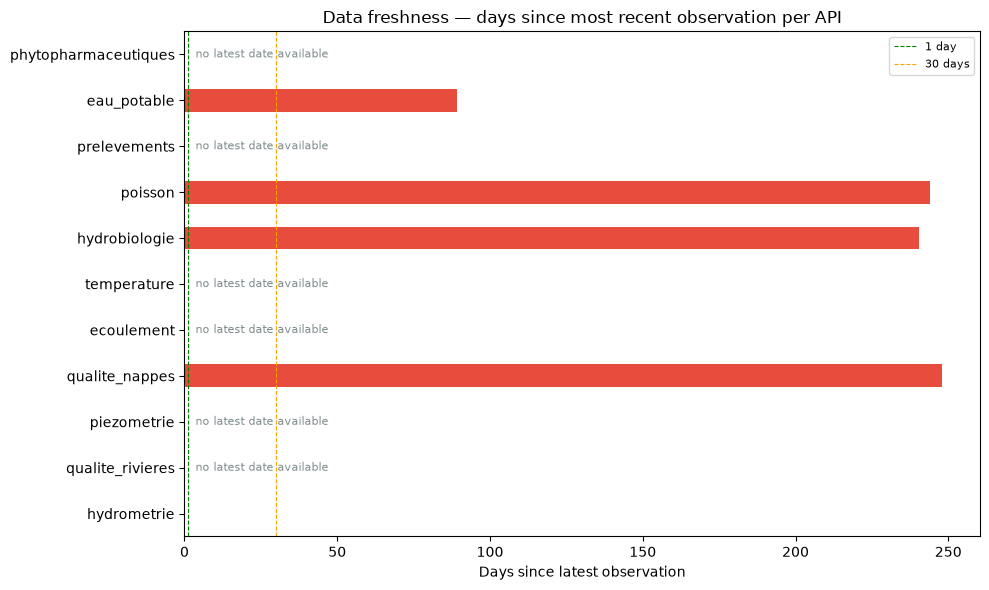

In [5]:
now = pd.Timestamp.now(tz="UTC")

latest_per_api = (
    df[df["latest"].notna()]
    .groupby("api")["latest"]
    .max()
)

# include all APIs, NaT for those with no latest date
all_api_names = list(station_apis.keys()) + list(national_apis.keys())
all_apis = pd.Series({name: latest_per_api.get(name) \
                      for name in all_api_names}, \
                     dtype="datetime64[ns, UTC]")

lag_days = (now - all_apis).dt.total_seconds() / 86400

colors = [
    "#95a5a6" if pd.isna(d) else
    "#2ecc71" if d < 1 else
    "#f39c12" if d < 30 else
    "#e74c3c"
    for d in lag_days
]

fig, ax = plt.subplots(figsize=(10, 6))
lag_days.fillna(0).plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Days since latest observation")
ax.set_title("Data freshness — days since most recent observation per API")
ax.axvline(1, color="green", linestyle="--", linewidth=0.8, label="1 day")
ax.axvline(30, color="orange", linestyle="--", linewidth=0.8, label="30 days")

# label APIs with no data
for i, (api, d) in enumerate(lag_days.items()):
    if pd.isna(d):
        ax.text(1, i, "  no latest date available", va="center", fontsize=8, color="#7f8c8d")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Total record counts per API

Volume of historical data available (sum across sampled stations).

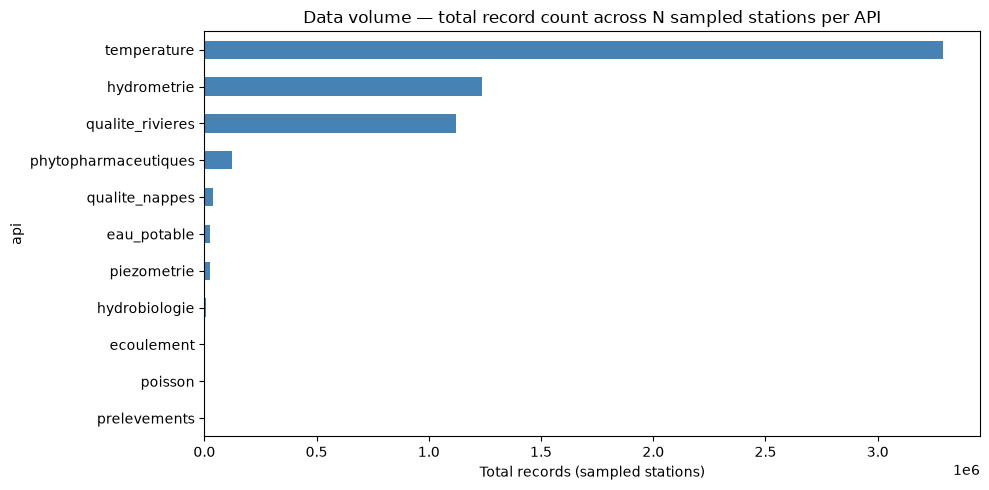

In [6]:
counts = (
    df[df["count"].notna()]
    .groupby("api")["count"]
    .sum()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Total records (sampled stations)")
ax.set_title("Data volume — total record count across N sampled stations per API")
plt.tight_layout()
plt.show()